# Импорт библиотек

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [37]:
df = pd.read_csv("datasets/dataset_1.csv")
df.head(3)

,id,time,processing_time,lon,lat,height,depth,course,angle,num_sattelites,...,speed,n/p,EI,EI 0-1,EI 1-2,EI 2-3,EI 3-4,EI 4-5,EI 5-6,EI 6-7
0,23061521,2025-10-07 22:18:02,2025-10-07 22:18:09.425,60.921372,53.208426,205.072378,4.5753,208,92.2,37,...,NaN,0.011135,6.580100e+04,7826.0000,14913.00000,17481.0,9998.0,5353.0,4888.0,2660.0
1,23061529,2025-10-07 22:18:08,2025-10-07 22:18:14.495,60.921372,53.208426,205.061214,4.6965,256,93.4,37,...,0.02020,0.008207,8.723352e+11,0.0202,0.00000,0.0,0.0,0.0,0.0,0.0
2,23061535,2025-10-07 22:18:13,2025-10-07 22:18:19.239,60.921372,53.208427,205.078345,4.8783,359,93.0,37,...,0.03636,0.005347,1.002123e+12,0.0000,0.03636,0.0,0.0,0.0,0.0,0.0


In [38]:
df['rod_change'].value_counts()

rod_change
0.00    165931
0.05        23
1.00        12
Name: count, dtype: int64

In [39]:
df.columns

Index(['id', 'time', 'processing_time', 'lon', 'lat', 'height', 'depth',
       'course', 'angle', 'num_sattelites', 'moving_type', 'rotation',
       'rod_change', 'pressure_air', 'pressure_axis', 'pressure_rotation',
       'electric_rotation', 'electric_pressure_axis', 'voltage_rotation',
       'voltage_pressure_axis', 'time_stamp', 'sequence_id', 'block_well_id',
       'rig_id', 'well_id', 'drilling_speed', 'rtk_status', 'd_depth',
       'd_time', 'speed', 'n/p', 'EI', 'EI 0-1', 'EI 1-2', 'EI 2-3', 'EI 3-4',
       'EI 4-5', 'EI 5-6', 'EI 6-7'],
      dtype='str')

In [40]:
df_clean = df.drop(columns=['id','electric_rotation', 'electric_pressure_axis', 'voltage_rotation',
       'voltage_pressure_axis', 'num_sattelites','moving_type', 'EI 0-1', 'EI 1-2', 'EI 2-3', 'EI 3-4',
       'EI 4-5', 'EI 5-6', 'EI 6-7','rod_change','sequence_id','rtk_status', 'rig_id', 'drilling_speed', 'time_stamp','block_well_id','time', 'processing_time'])

In [41]:
df['speed'].corr(df['d_depth']/df['d_time'])

np.float64(1.0)

In [42]:
df_clean.dropna(inplace=True)

In [43]:
df_clean.head()


,lon,lat,height,depth,course,angle,rotation,pressure_air,pressure_axis,pressure_rotation,well_id,d_depth,d_time,speed,n/p,EI
1,60.921372,53.208426,205.061214,4.6965,256,93.4,104.892,497,12781,13144,25512,0.1212,6.0,0.020200,0.008207,8.723352e+11
2,60.921372,53.208427,205.078345,4.8783,359,93.0,101.430,501,18971,18936,25512,0.1818,5.0,0.036360,0.005347,1.002123e+12
3,60.921373,53.208425,205.054763,5.0298,170,92.1,101.430,544,20153,18184,25512,0.1515,5.0,0.030300,0.005033,1.226741e+12
4,60.921372,53.208425,205.065585,5.1813,218,93.0,102.714,559,20162,17445,25512,0.1515,5.0,0.030300,0.005094,1.192317e+12
5,60.921372,53.208427,205.090648,5.3934,341,94.3,47.724,558,1233,10808,25512,0.2121,27.0,0.007856,0.038706,8.095960e+10


In [44]:
df_clean = df_clean[df_clean['speed']<0.1]

(array([   504.,    176.,    320.,    579.,   1204.,   3764.,   6874.,
        113064.,    206.,  38117.]),
 array([  0.144 ,  14.0874,  28.0308,  41.9742,  55.9176,  69.861 ,
         83.8044,  97.7478, 111.6912, 125.6346, 139.578 ]),
 <BarContainer object of 10 artists>)

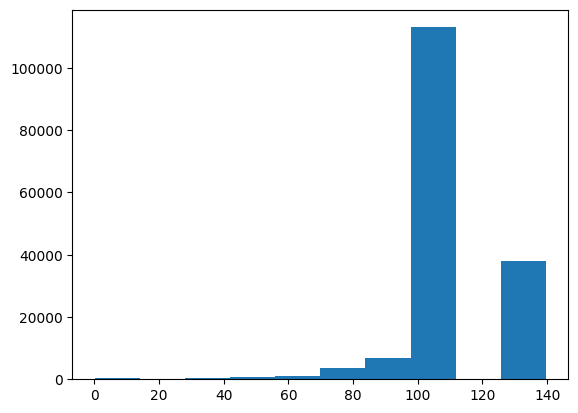

In [45]:
plt.hist(df_clean['rotation'])

(array([51297., 90405., 18013.,  3430.,   714.,   229.,   265.,   212.,
          105.,   138.]),
 array([7.11635117e-07, 9.99964047e-03, 1.99985693e-02, 2.99974981e-02,
        3.99964270e-02, 4.99953558e-02, 5.99942847e-02, 6.99932135e-02,
        7.99921423e-02, 8.99910712e-02, 9.99900000e-02]),
 <BarContainer object of 10 artists>)

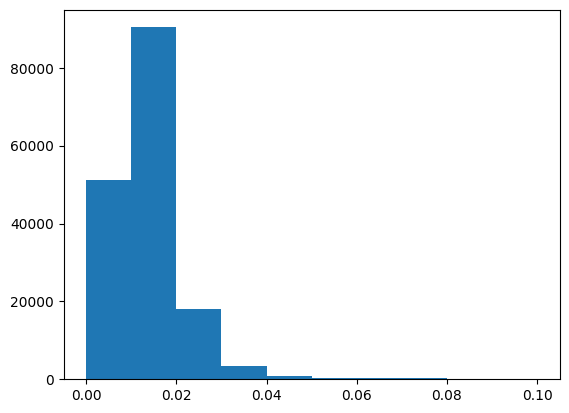

In [46]:
plt.hist(df_clean['speed'])

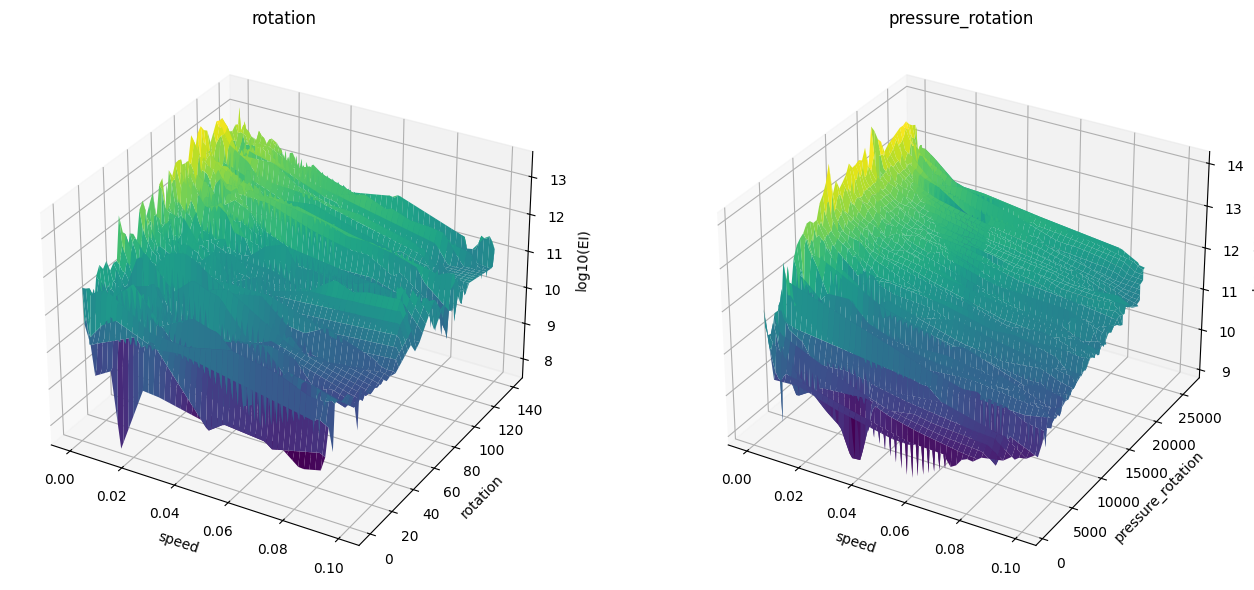

In [69]:
# %%
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata

x = df_clean['speed'].values
z = np.log10(np.abs(df_clean['EI'].values) + 1e-12)

y1 = df_clean['rotation'].values
y2 = df_clean['pressure_rotation'].values

fig = plt.figure(figsize=(14,6))

# ===== Первый subplot (rotation) =====
ax1 = fig.add_subplot(121, projection='3d')

xi = np.linspace(x.min(), x.max(), 100)
yi1 = np.linspace(y1.min(), y1.max(), 100)
xi1, yi1 = np.meshgrid(xi, yi1)

zi1 = griddata((x, y1), z, (xi1, yi1), method='linear')

surf1 = ax1.plot_surface(xi1, yi1, zi1, cmap='viridis', edgecolor='none')
ax1.set_xlabel('speed')
ax1.set_ylabel('rotation')
ax1.set_zlabel('log10(EI)')
ax1.set_title('rotation')

# ===== Второй subplot (pressure_rotation) =====
ax2 = fig.add_subplot(122, projection='3d')

yi2 = np.linspace(y2.min(), y2.max(), 100)
xi2, yi2 = np.meshgrid(xi, yi2)

zi2 = griddata((x, y2), z, (xi2, yi2), method='linear')

surf2 = ax2.plot_surface(xi2, yi2, zi2, cmap='viridis', edgecolor='none')
ax2.set_xlabel('speed')
ax2.set_ylabel('pressure_rotation')
ax2.set_zlabel('log10(EI)')
ax2.set_title('pressure_rotation')


plt.tight_layout()
plt.show()